In [1]:
#1.Imports
# numpy: operaciones numéricas eficientes (arrays, logaritmos, medias, etc.)
import numpy as np

# pandas: manipulación de datos tabulares (DataFrames)
import pandas as pd

# GEOparse: descarga y lectura de datasets del repositorio GEO
# nos permite acceder directamente a datasets de expresión génica
import GEOparse

# matplotlib: generación de gráficos
import matplotlib.pyplot as plt

# Pipeline: permite encadenar pasos (preprocesado + modelo)
# clave para evitar data leakage dentro de validación cruzada
from sklearn.pipeline import Pipeline

# StandardScaler: normaliza variables (media=0, var=1)
# necesario para modelos sensibles a escala (SVM, regresión)
from sklearn.preprocessing import StandardScaler

# VarianceThreshold: elimina variables con poca variabilidad
# útil para quitar genes irrelevantes
# SelectKBest: selecciona las K mejores variables según un criterio
# f_classif: ANOVA, mide relación entre variable y clase
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# StratifiedKFold: validación cruzada manteniendo proporción de clases
# cross_validate: ejecuta CV y devuelve métricas
from sklearn.model_selection import StratifiedKFold, cross_validate

# Modelos de clasificación
from sklearn.linear_model import LogisticRegression  # modelo lineal interpretable
from sklearn.svm import SVC                           # SVM (potente en alta dimensión)
from sklearn.ensemble import RandomForestClassifier   # modelo robusto basado en árboles

import time
import winsound  # solo Windows

In [2]:
#2. CONFIGURACIÓN

# Fijamos semilla para reproducibilidad
# esto asegura que los resultados sean replicables
RANDOM_STATE = 42

# Número de variables (genes) que se seleccionarán
# hiperparámetro importante que controla complejidad del modelo
K_VALUES = [20, 50, 100, 500, 1000]

In [3]:
#3. Dataset
# Descargamos el dataset GSE2034 desde GEO
# si ya está descargado, se reutiliza (no descarga otra vez)
gse = GEOparse.get_GEO("GSE2034", destdir="../data")

27-Mar-2026 10:33:54 DEBUG utils - Directory ../data already exists. Skipping.
27-Mar-2026 10:33:54 INFO GEOparse - File already exist: using local version.
27-Mar-2026 10:33:54 INFO GEOparse - Parsing ../data\GSE2034_family.soft.gz: 
27-Mar-2026 10:33:54 DEBUG GEOparse - DATABASE: GeoMiame
27-Mar-2026 10:33:54 DEBUG GEOparse - SERIES: GSE2034
27-Mar-2026 10:33:54 DEBUG GEOparse - PLATFORM: GPL96
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36777
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36778
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36779
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36780
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36781
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36782
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36783
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36784
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36785
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM36786
27-Mar-2026 10:33:55 DEBUG GEOparse - SAMPLE: GSM3

In [4]:
#4. Matriz de Expresión (X)
# Creamos un diccionario donde:
# clave = muestra (paciente)
# valor = vector de expresión génica
expr_data = {}

# Iteramos sobre todas las muestras del dataset
for gsm_name, gsm in gse.gsms.items():
    
    # gsm.table contiene los datos del microarray
    # ID_REF = identificador del gen/probe
    # VALUE = nivel de expresión
    
    # Convertimos la tabla en un vector indexado por genes
    expr_data[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

# Convertimos el diccionario en DataFrame
# filas = muestras, columnas = genes
X = pd.DataFrame(expr_data).T

print("Shape X:", X.shape)

Shape X: (286, 22283)


In [5]:
#5. EXTRACCIÓN DE LABELS
# Lista donde guardaremos la variable objetivo (metástasis sí/no)
y = []

# Iteramos sobre cada muestra
for gsm_name, gsm in gse.gsms.items():
    
    # Obtenemos metadatos clínicos
    chars = gsm.metadata.get("characteristics_ch1", [])
    
    label = None
    
    # Buscamos el campo relevante
    for c in chars:
        c = c.lower()
        
        # Este dataset codifica la variable así:
        # "bone relapses (1=yes, 0=no): X"
        if "bone relapses" in c:
            
            # Extraemos el valor numérico (0 o 1)
            label = int(c.split(":")[-1].strip())
    
    # Si no encontramos etiqueta → error
    if label is None:
        raise ValueError(f"No se pudo extraer label para {gsm_name}")
    
    y.append(label)

# Convertimos a array numpy
y = np.array(y)

# Comprobamos distribución de clases
# importante para detectar errores en etiquetas
print("Distribución de clases:", np.bincount(y))

# Verificación de que hay exactamente dos clases
assert len(np.unique(y)) == 2, "Error: solo hay una clase"

Distribución de clases: [217  69]


In [6]:
#6. Transformación Logaritmica
# Aplicamos log2(x + 1)
# motivo:
# - los datos de microarray son altamente asimétricos
# - el log estabiliza la varianza y mejora modelos
X_log = np.log2(X + 1)

In [8]:
# ============================================================
# 7. PIPELINES Y EVALUACIÓN
# ============================================================

# Lista donde guardaremos los resultados de todos los experimentos
results = []

# Validación cruzada estratificada (mantiene proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Iteramos sobre los distintos valores de K (nº de features)
for K in K_VALUES:

    # Definimos pipelines para este valor de K
    pipelines = {

        # --------------------------------------------------
        # BASELINE (sin selección de variables)
        # --------------------------------------------------
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),  # elimina genes con baja varianza
            ("scaler", StandardScaler()),                     # normaliza datos
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # LOGISTIC REGRESSION + ANOVA
        # --------------------------------------------------
        f"LR + SelectKBest (K={K})": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),  # selecciona K genes más relevantes
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # SVM (RBF) + SELECCIÓN
        # --------------------------------------------------
        f"SVM (RBF) + SelectKBest (K={K})": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # RANDOM FOREST + SELECCIÓN
        # --------------------------------------------------
        f"RF + SelectKBest (K={K})": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE
            ))
        ])
    }

    # ============================================================
    # EVALUACIÓN
    # ============================================================
    for name, pipe in pipelines.items():

        # Ejecutamos CV y obtenemos accuracy en cada fold
        scores = cross_validate(
            pipe,
            X_log,
            y,
            cv=cv,
            scoring="accuracy",
            n_jobs=2,                # paralelización controlada
            pre_dispatch="2*n_jobs"
        )

        # Guardamos resultados agregados
        results.append({
            "model": name,
            "K": K,
            "mean_accuracy": scores["test_score"].mean(),
            "std_accuracy": scores["test_score"].std()
        })

# ============================================================
# RESULTADOS
# ============================================================

# Convertimos resultados a DataFrame
results_df = pd.DataFrame(results)

# Mostramos resultados
print(results_df)

                               model     K  mean_accuracy  std_accuracy
0                        LR baseline    20       0.811252      0.019752
1            LR + SelectKBest (K=20)    20       0.716999      0.043170
2     SVM (RBF) + SelectKBest (K=20)    20       0.737810      0.024194
3            RF + SelectKBest (K=20)    20       0.731034      0.045831
4                        LR baseline    50       0.811252      0.019752
5            LR + SelectKBest (K=50)    50       0.699577      0.069856
6     SVM (RBF) + SelectKBest (K=50)    50       0.724017      0.050846
7            RF + SelectKBest (K=50)    50       0.734422      0.036073
8                        LR baseline   100       0.811252      0.019752
9           LR + SelectKBest (K=100)   100       0.688869      0.050907
10   SVM (RBF) + SelectKBest (K=100)   100       0.744828      0.041877
11          RF + SelectKBest (K=100)   100       0.730792      0.040715
12                       LR baseline   500       0.811252      0

In [10]:
# ============================================================
# 8. VALIDACIÓN CRUZADA (EXPERIMENTO CON DISTINTOS K)
# ============================================================

import time
from sklearn.feature_selection import mutual_info_classif, RFE

# Guardamos tiempo total del experimento
total_start = time.time()

# Validación cruzada estratificada (mantiene proporción de clases)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Lista donde guardaremos TODOS los resultados
all_results = []

# Loop sobre distintos valores de K (número de genes seleccionados)
for K in K_VALUES:

    print(f"\nEvaluando K = {K}")

    # ============================================================
    # PIPELINES (dependen de K)
    # ============================================================
    pipelines = {

        # --------------------------------------------------
        # BASELINE (sin selección de variables)
        # --------------------------------------------------
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # ANOVA
        # --------------------------------------------------
        "LR + ANOVA": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(score_func=f_classif, k=K)),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # MUTUAL INFORMATION
        # --------------------------------------------------
        "LR + MutualInfo": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(
                score_func=lambda X, y: mutual_info_classif(X, y, random_state=RANDOM_STATE),
                k=K
            )),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ]),

        # --------------------------------------------------
        # RFE
        # --------------------------------------------------
        "LR + RFE": Pipeline([
            ("variance", VarianceThreshold(threshold=0.01)),
            ("scaler", StandardScaler()),
            ("select", RFE(
                estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_features_to_select=K,
                step=50
            )),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
        ])
    }

    # ============================================================
    # EVALUACIÓN
    # ============================================================
    for name, pipe in pipelines.items():

        # Evitar RFE muy grande
        if name == "LR + RFE" and K > 1000:
            continue

        print(f"K={K} | Modelo: {name}")

        start = time.time()

        scores = cross_validate(
            pipe,
            X_log,
            y,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "f1": "f1",
                "accuracy": "accuracy"
            },
            return_train_score=False,
            n_jobs=3,
            pre_dispatch="2*n_jobs"
        )

        end = time.time()
        print(f"Tiempo: {end - start:.2f} s")

        all_results.append({
            "Model": name,
            "K": K,
            "ROC-AUC": np.mean(scores["test_roc_auc"]),
            "F1": np.mean(scores["test_f1"]),
            "Accuracy": np.mean(scores["test_accuracy"])
        })

# ============================================================
# FIN BLOQUE 8
# ============================================================

total_end = time.time()
print(f"\nTiempo total: {total_end - total_start:.2f} s")

print("\n=== FIN EXPERIMENTO K ===")


Evaluando K = 20
K=20 | Modelo: LR baseline
Tiempo: 3.56 s
K=20 | Modelo: LR + ANOVA
Tiempo: 1.31 s
K=20 | Modelo: LR + MutualInfo
Tiempo: 58.80 s
K=20 | Modelo: LR + RFE
Tiempo: 151.49 s

Evaluando K = 50
K=50 | Modelo: LR baseline
Tiempo: 2.32 s
K=50 | Modelo: LR + ANOVA
Tiempo: 1.64 s
K=50 | Modelo: LR + MutualInfo
Tiempo: 57.82 s
K=50 | Modelo: LR + RFE
Tiempo: 151.61 s

Evaluando K = 100
K=100 | Modelo: LR baseline
Tiempo: 2.08 s
K=100 | Modelo: LR + ANOVA
Tiempo: 1.47 s
K=100 | Modelo: LR + MutualInfo
Tiempo: 62.82 s
K=100 | Modelo: LR + RFE
Tiempo: 149.87 s

Evaluando K = 500
K=500 | Modelo: LR baseline
Tiempo: 2.09 s
K=500 | Modelo: LR + ANOVA
Tiempo: 1.51 s
K=500 | Modelo: LR + MutualInfo
Tiempo: 61.32 s
K=500 | Modelo: LR + RFE
Tiempo: 151.22 s

Evaluando K = 1000
K=1000 | Modelo: LR baseline
Tiempo: 1.97 s
K=1000 | Modelo: LR + ANOVA
Tiempo: 1.46 s
K=1000 | Modelo: LR + MutualInfo
Tiempo: 59.84 s
K=1000 | Modelo: LR + RFE
Tiempo: 147.94 s

Tiempo total: 1072.14 s

=== FIN E

In [11]:
# ============================================================
# 9. EXPERIMENTO L1 (SPARSIDAD)
# ============================================================

print("\n=== EXPERIMENTO L1 ===")

# Valores de regularización
C_VALUES = [0.01, 0.1, 1]

l1_results = []

for C in C_VALUES:

    print(f"\nEvaluando L1 con C = {C}")

    pipe = Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="saga",
            max_iter=5000,
            C=C,
            random_state=RANDOM_STATE
        ))
    ])

    start = time.time()

    scores = cross_validate(
        pipe,
        X_log,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "accuracy": "accuracy"
        },
        return_train_score=False,
        n_jobs=2,
        pre_dispatch="2*n_jobs"
    )

    end = time.time()
    print(f"Tiempo: {end - start:.2f} s")

    l1_results.append({
        "Model": "LR L1",
        "C": C,
        "ROC-AUC": np.mean(scores["test_roc_auc"]),
        "F1": np.mean(scores["test_f1"]),
        "Accuracy": np.mean(scores["test_accuracy"])
    })

# Convertimos a DataFrame
l1_df = pd.DataFrame(l1_results)

print("\n=== RESULTADOS L1 ===")
print(l1_df)


=== EXPERIMENTO L1 ===

Evaluando L1 con C = 0.01
Tiempo: 3.32 s

Evaluando L1 con C = 0.1
Tiempo: 385.48 s

Evaluando L1 con C = 1
Tiempo: 623.56 s

=== RESULTADOS L1 ===
   Model     C   ROC-AUC        F1  Accuracy
0  LR L1  0.01  0.500000  0.000000  0.758742
1  LR L1  0.10  0.592138  0.120948  0.744828
2  LR L1  1.00  0.640148  0.352074  0.758863


In [20]:
#Bloque 9 Alternativo-No lineal Random Forest
# ============================================================
# 1. RANDOM FOREST (MODELO NO LINEAL)
# ============================================================

import time  # sirve para medir cuánto tarda cada parte del código
from sklearn.ensemble import RandomForestClassifier  # modelo de árboles (no lineal)

print("\n=== EXPERIMENTO RANDOM FOREST ===")

rf_results = []  # lista donde guardaremos los resultados del modelo

total_start = time.time()  # inicio del tiempo total del bloque

# Validación cruzada estratificada:
# divide los datos en 5 partes manteniendo proporción de clases
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Definimos el pipeline (flujo de trabajo del modelo)
rf_model = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),  # elimina variables casi constantes
    ("model", RandomForestClassifier(
        n_estimators=200,        # número de árboles en el bosque
        max_depth=None,          # profundidad ilimitada (árboles complejos)
        random_state=RANDOM_STATE,
        n_jobs=2                 # usa 2 cores para entrenar árboles en paralelo
    ))
])

print("Entrenando Random Forest...")

start = time.time()  # inicio del tiempo del modelo

# cross_validate:
# entrena y evalúa el modelo en distintos splits de los datos
scores = cross_validate(
    rf_model,
    X_log,   # datos (genes)
    y,       # etiquetas (metástasis sí/no)
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",   # métrica principal (capacidad de discriminación)
        "f1": "f1",             # equilibrio entre precisión y recall
        "accuracy": "accuracy"  # porcentaje de aciertos
    },
    return_train_score=False,  # no guardamos métricas de entrenamiento
    n_jobs=1   # importante: evitamos paralelización doble (RF ya usa cores)
)

end = time.time()
print(f"Tiempo RF: {end - start:.2f} s")  # tiempo que ha tardado el modelo

# Guardamos los resultados promediados de los folds
rf_results.append({
    "Model": "Random Forest",
    "K": "N/A",  # no usamos selección de variables aquí
    "ROC-AUC": np.mean(scores["test_roc_auc"]),
    "F1": np.mean(scores["test_f1"]),
    "Accuracy": np.mean(scores["test_accuracy"])
})

rf_df = pd.DataFrame(rf_results)  # convertimos a tabla

print("\nResultados Random Forest:")
print(rf_df)


# ============================================================
# 2. SVM (LINEAL Y NO LINEAL)
# ============================================================

from sklearn.svm import SVC  # modelo de máquinas de soporte vectorial

print("\n=== EXPERIMENTO SVM ===")

svm_results = []  # lista de resultados

# ============================================================
# SVM LINEAL
# ============================================================

print("\nEntrenando SVM Linear...")

start = time.time()

# Pipeline para SVM lineal
svm_linear = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),  # filtrado inicial
    ("scaler", StandardScaler()),  # normaliza datos (muy importante para SVM)
    ("model", SVC(
        kernel="linear",  # frontera de decisión lineal
        probability=True, # necesario para calcular ROC-AUC
        random_state=RANDOM_STATE
    ))
])

scores = cross_validate(
    svm_linear,
    X_log,
    y,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "f1": "f1",
        "accuracy": "accuracy"
    },
    n_jobs=2  # paralelizamos folds
)

end = time.time()
print(f"Tiempo SVM Linear: {end - start:.2f} s")

# Guardamos resultados
svm_results.append({
    "Model": "SVM Linear",
    "K": "N/A",
    "C": None,
    "Type": "SVM",
    "ROC-AUC": np.mean(scores["test_roc_auc"]),
    "F1": np.mean(scores["test_f1"]),
    "Accuracy": np.mean(scores["test_accuracy"])
})


# ============================================================
# SVM RBF (NO LINEAL)
# ============================================================

print("\nEntrenando SVM RBF...")

start = time.time()

# Pipeline para SVM no lineal
svm_rbf = Pipeline([
    ("variance", VarianceThreshold(threshold=0.01)),
    ("scaler", StandardScaler()),  # necesario para que SVM funcione bien
    ("model", SVC(
        kernel="rbf",  # kernel radial → permite relaciones no lineales
        probability=True,
        random_state=RANDOM_STATE
    ))
])

scores = cross_validate(
    svm_rbf,
    X_log,
    y,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "f1": "f1",
        "accuracy": "accuracy"
    },
    n_jobs=2
)

end = time.time()
print(f"Tiempo SVM RBF: {end - start:.2f} s")

# Guardamos resultados
svm_results.append({
    "Model": "SVM RBF",
    "K": "N/A",
    "C": None,
    "Type": "SVM",
    "ROC-AUC": np.mean(scores["test_roc_auc"]),
    "F1": np.mean(scores["test_f1"]),
    "Accuracy": np.mean(scores["test_accuracy"])
})


# ============================================================
# RESULTADOS SVM
# ============================================================

svm_df = pd.DataFrame(svm_results)  # convertimos a DataFrame
svm_df["Type"] = "SVM"
svm_df["C"] = np.nan
svm_df["K"] = "N/A"

# Orden de columnas consistente con el resto
svm_df = svm_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]

print("\n=== RESULTADOS SVM ===")
print(svm_df)


# ============================================================
# FIN BLOQUE
# ============================================================

total_end = time.time()
print(f"\nTiempo total bloque no lineal: {total_end - total_start:.2f} s")

# Sonido al terminar (solo Windows)
import winsound
winsound.Beep(1000, 500)

print("\n=== FIN EXPERIMENTO NO LINEAL ===")


=== EXPERIMENTO RANDOM FOREST ===
Entrenando Random Forest...
Tiempo RF: 9.22 s

Resultados Random Forest:
           Model    K   ROC-AUC    F1  Accuracy
0  Random Forest  N/A  0.685045  0.05  0.765638

=== EXPERIMENTO SVM ===

Entrenando SVM Linear...
Tiempo SVM Linear: 8.37 s

Entrenando SVM RBF...
Tiempo SVM RBF: 10.08 s

=== RESULTADOS SVM ===
        Model    K   C Type   ROC-AUC        F1  Accuracy
0  SVM Linear  N/A NaN  SVM  0.740350  0.402077  0.786751
1     SVM RBF  N/A NaN  SVM  0.736731  0.000000  0.758742

Tiempo total bloque no lineal: 27.67 s

=== FIN EXPERIMENTO NO LINEAL ===


In [21]:
# 10. RESULTADOS (EXPERIMENTO K)

results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values("ROC-AUC", ascending=False)

print("\n=== RESULTADOS EXPERIMENTO K ===")
print(results_df)


# ============================================================
# 10.1. RESULTADOS L1
# ============================================================

l1_df = pd.DataFrame(l1_results)
l1_df = l1_df.sort_values("ROC-AUC", ascending=False)

print("\n=== RESULTADOS L1 ===")
print(l1_df)


# ============================================================
# 10.2. RESULTADOS RANDOM FOREST
# ============================================================

rf_df["Type"] = "RF"
rf_df["C"] = np.nan
rf_df["K"] = "N/A"

rf_df = rf_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]

print("\n=== RESULTADOS RANDOM FOREST ===")
print(rf_df)


# ============================================================
# RESULTADOS UNIFICADOS (K + L1 + RF)
# ============================================================

# Añadimos tipo a K
results_df["Type"] = "K-based"
results_df["C"] = np.nan

# Añadimos tipo a L1
l1_df["Type"] = "L1"
l1_df["K"] = "auto"

# Orden de columnas consistente
results_df = results_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]
l1_df = l1_df[["Model", "K", "C", "Type", "ROC-AUC", "F1", "Accuracy"]]

# Concatenamos todo
combined_df = pd.concat([results_df, l1_df, rf_df, svm_df], ignore_index=True)

# Ordenamos por rendimiento
combined_df = combined_df.sort_values("ROC-AUC", ascending=False)

print("\nTipos de modelos en combined_df:")
print(combined_df["Type"].value_counts())


=== RESULTADOS EXPERIMENTO K ===
              Model     K   ROC-AUC        F1  Accuracy
0       LR baseline    20  0.749616  0.485987  0.811252
8       LR baseline   100  0.749616  0.485987  0.811252
16      LR baseline  1000  0.749616  0.485987  0.811252
12      LR baseline   500  0.749616  0.485987  0.811252
4       LR baseline    50  0.749616  0.485987  0.811252
19         LR + RFE  1000  0.704904  0.313679  0.769328
18  LR + MutualInfo  1000  0.699329  0.339394  0.762250
14  LR + MutualInfo   500  0.679187  0.426491  0.762129
15         LR + RFE   500  0.665479  0.326491  0.776346
17       LR + ANOVA  1000  0.662481  0.337842  0.758863
13       LR + ANOVA   500  0.651593  0.280037  0.727284
10  LR + MutualInfo   100  0.640749  0.350020  0.709498
6   LR + MutualInfo    50  0.622552  0.300471  0.688808
1        LR + ANOVA    20  0.622219  0.251604  0.716999
2   LR + MutualInfo    20  0.595362  0.214364  0.695886
11         LR + RFE   100  0.589120  0.274650  0.713188
7          LR 

In [22]:
# 11. GUARDADO


import os

os.makedirs("../results", exist_ok=True)

# Guardamos por separado (más limpio)
results_df.to_csv("../results/results_k_based.csv", index=False)
l1_df.to_csv("../results/results_l1.csv", index=False)

# Guardamos combinado (muy útil)
combined_df.to_csv("../results/results_combined.csv", index=False)

print("Resultados guardados correctamente")

Resultados guardados correctamente


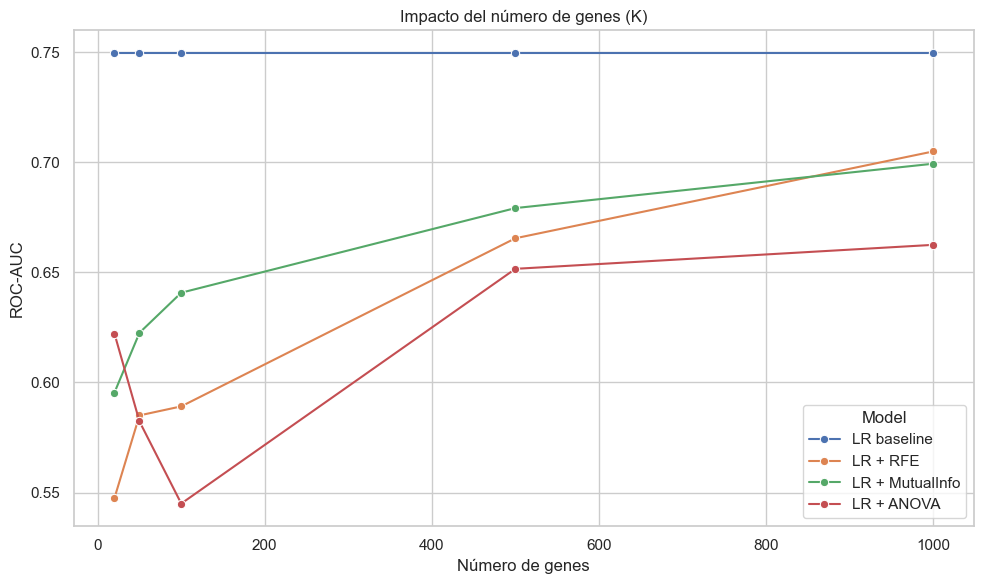

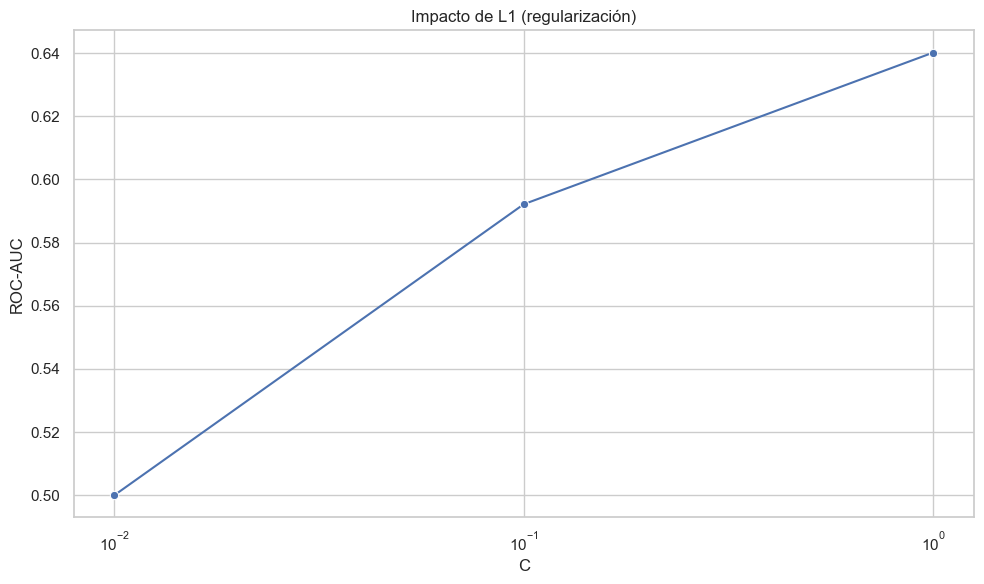

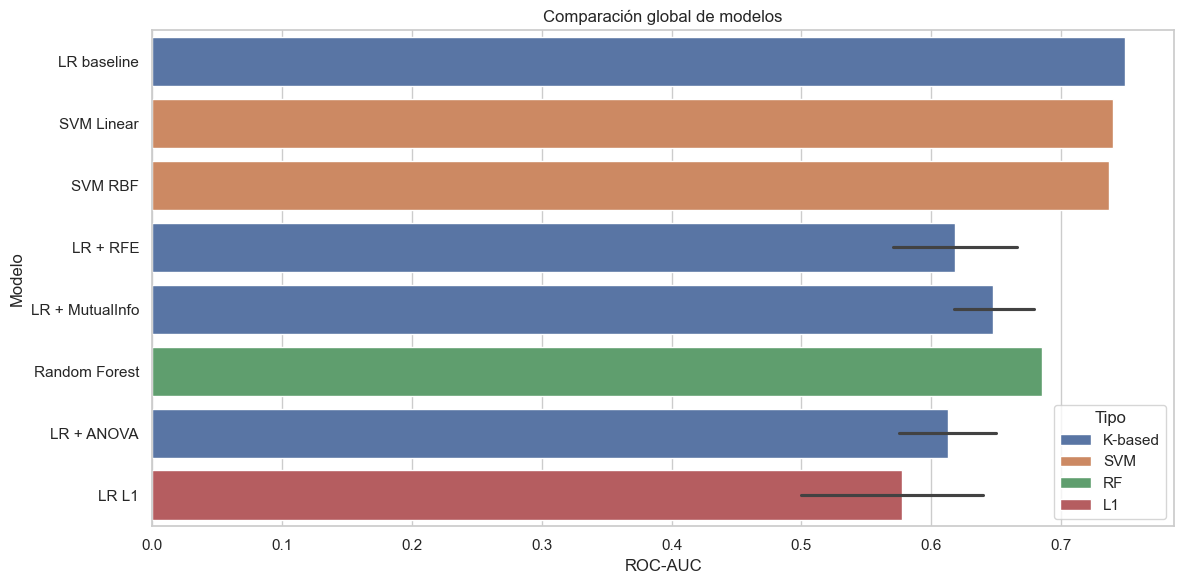

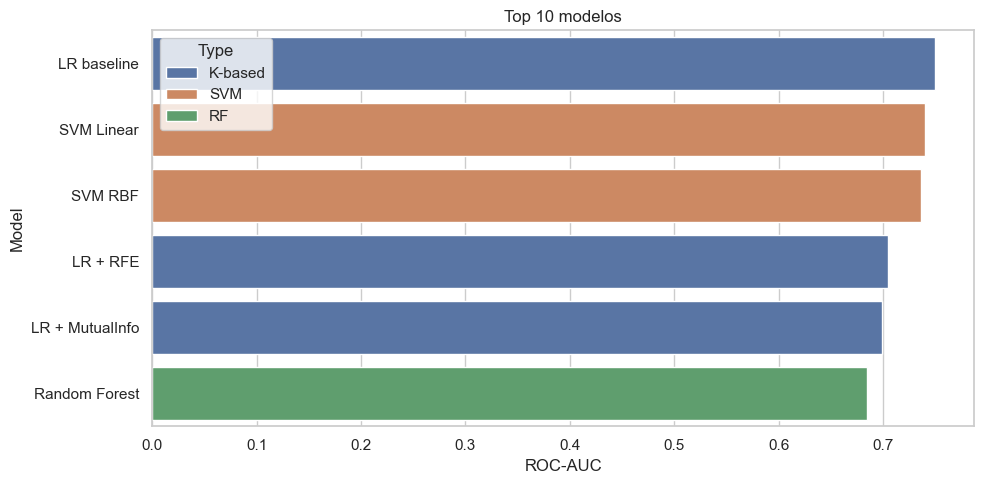

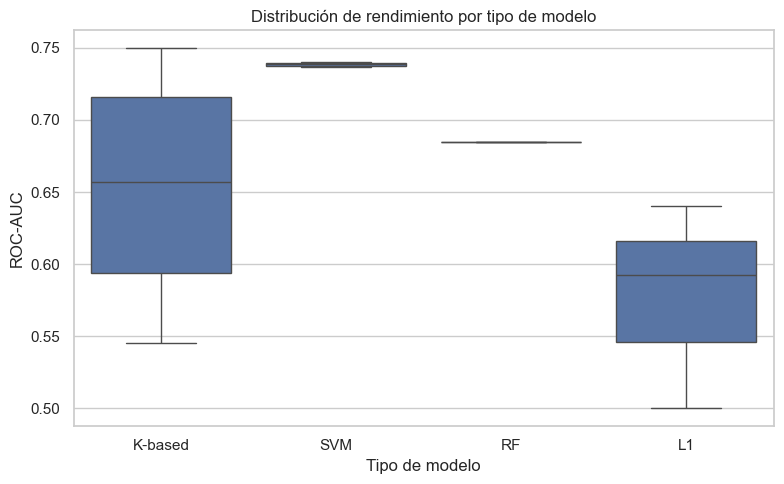


=== FIN VISUALIZACIÓN COMPLETA ===


In [23]:
# 12. VISUALIZACIÓN COMPLETA (TODOS LOS MODELOS)

import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")


# ------------------------------------------------------------
# 1. IMPACTO DE K (SOLO MODELOS K-based)
# ------------------------------------------------------------
# Filtramos solo modelos que usan K
df_k = combined_df[combined_df["Type"] == "K-based"]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_k,
    x="K",
    y="ROC-AUC",
    hue="Model",
    marker="o"
)

plt.title("Impacto del número de genes (K)")
plt.xlabel("Número de genes")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 2. IMPACTO DE L1 (REGULARIZACIÓN)
# ------------------------------------------------------------
# Filtramos solo L1
df_l1 = combined_df[combined_df["Type"] == "L1"]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=df_l1,
    x="C",
    y="ROC-AUC",
    marker="o"
)

plt.xscale("log")

plt.title("Impacto de L1 (regularización)")
plt.xlabel("C")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 3. COMPARACIÓN GLOBAL (TODOS LOS MODELOS)
# ------------------------------------------------------------
# ESTE ES EL GRÁFICO CLAVE

plt.figure(figsize=(12, 6))

plot_df = combined_df.sort_values("ROC-AUC", ascending=False)

sns.barplot(
    data=plot_df,
    x="ROC-AUC",
    y="Model",
    hue="Type"
)

plt.title("Comparación global de modelos")
plt.xlabel("ROC-AUC")
plt.ylabel("Modelo")

plt.legend(title="Tipo")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 4. TOP MODELOS (más limpio)
# ------------------------------------------------------------

top_models = combined_df.sort_values("ROC-AUC", ascending=False).head(10)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=top_models,
    x="ROC-AUC",
    y="Model",
    hue="Type"
)

plt.title("Top 10 modelos")
plt.xlabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 5. COMPARACIÓN POR TIPO DE MODELO
# ------------------------------------------------------------
# Para ver diferencias entre enfoques

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=combined_df,
    x="Type",
    y="ROC-AUC"
)

plt.title("Distribución de rendimiento por tipo de modelo")
plt.xlabel("Tipo de modelo")
plt.ylabel("ROC-AUC")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# FIN BLOQUE
# ------------------------------------------------------------
print("\n=== FIN VISUALIZACIÓN COMPLETA ===")

In [26]:
# 13. ANÁLISIS DE ESTABILIDAD DE GENES (¿HAY FIRMA?)
# Este bloque intenta responder:
# ¿los mismos genes aparecen siempre como importantes?

from collections import Counter  # para contar frecuencias
import numpy as np

print("\n=== ANÁLISIS DE ESTABILIDAD DE GENES ===")

# Número de genes que queremos analizar en cada fold
TOP_K_GENES = 50

# Lista donde guardaremos los genes importantes de cada fold
selected_genes_all_folds = []

# Volvemos a definir la validación cruzada (igual que antes)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Iteramos sobre cada fold manualmente
for fold, (train_idx, test_idx) in enumerate(cv.split(X_log, y)):

    print(f"\nFold {fold+1}")

    # Dividimos datos en train/test
    X_train, X_test = X_log.iloc[train_idx], X_log.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Pipeline igual que tu baseline (MUY IMPORTANTE: coherencia)
    pipe = Pipeline([
        ("variance", VarianceThreshold(threshold=0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
    ])

    # Entrenamos el modelo SOLO con datos de entrenamiento
    pipe.fit(X_train, y_train)

    # --------------------------------------------------------
    # EXTRAEMOS LOS COEFICIENTES DEL MODELO
    # --------------------------------------------------------

    # Los coeficientes indican la importancia de cada gen
    coefs = pipe.named_steps["model"].coef_[0]

    # IMPORTANTE:
    # usamos valor absoluto porque:
    # + peso positivo → aumenta probabilidad
    # + peso negativo → la reduce
    # pero ambos son importantes
    abs_coefs = np.abs(coefs)

    # --------------------------------------------------------
    # SELECCIONAMOS LOS GENES MÁS IMPORTANTES
    # --------------------------------------------------------

    # Índices de los TOP_K_GENES genes más importantes
    top_indices = np.argsort(abs_coefs)[-TOP_K_GENES:]

    # Guardamos los nombres (o índices si no tienes nombres)
    selected_genes_all_folds.extend(top_indices)

    print(f"Top {TOP_K_GENES} genes extraídos")


# ============================================================
# CONTAMOS FRECUENCIAS DE APARICIÓN
# ============================================================

# Cuántas veces aparece cada gen en los folds
gene_counts = Counter(selected_genes_all_folds)

# Convertimos a lista ordenada
gene_freq = sorted(gene_counts.items(), key=lambda x: x[1], reverse=True)

print("\n=== GENES MÁS FRECUENTES ===")

# Mostramos los más repetidos
for gene, count in gene_freq[:20]:
    print(f"Gen {gene} aparece en {count} folds")


=== ANÁLISIS DE ESTABILIDAD DE GENES ===

Fold 1
Top 50 genes extraídos

Fold 2
Top 50 genes extraídos

Fold 3
Top 50 genes extraídos

Fold 4
Top 50 genes extraídos

Fold 5
Top 50 genes extraídos

=== GENES MÁS FRECUENTES ===
Gen 11162 aparece en 4 folds
Gen 10043 aparece en 4 folds
Gen 8601 aparece en 4 folds
Gen 6817 aparece en 4 folds
Gen 21912 aparece en 3 folds
Gen 11240 aparece en 3 folds
Gen 4933 aparece en 3 folds
Gen 10369 aparece en 3 folds
Gen 17042 aparece en 3 folds
Gen 7421 aparece en 3 folds
Gen 10054 aparece en 3 folds
Gen 8489 aparece en 3 folds
Gen 14062 aparece en 3 folds
Gen 7756 aparece en 2 folds
Gen 8380 aparece en 2 folds
Gen 8022 aparece en 2 folds
Gen 474 aparece en 2 folds
Gen 9562 aparece en 2 folds
Gen 20411 aparece en 2 folds
Gen 20159 aparece en 2 folds
